In [1]:
from gpu_odes.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [2]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wa', 6.0e9*2*pi, is_excitation=True)
sim.add_param('wb', 3.8e9*2*pi)
sim.add_param('wc', 7.5e9*2*pi)
sim.add_param('logchi', 6.5) # in MHz
sim.add_param('logka', 6) # in MHz
sim.add_param('kb', 10e6 * 2 * np.pi)
sim.add_param('kc', 4e6 * 2 * np.pi)
sim.add_param('gab', 10e6 * 2 * np.pi)
sim.add_param('gbc', 10e6 * 2 * np.pi)
sim.add_param('g3', 50e6 * 2 * np.pi)
sim.add_param('g4', 10e6 * 2 * np.pi)
sim.add_param('gr', 1e6 * 2 * np.pi)
sim.add_paramsweep('qbstate', -1, 1, 2)

sim.add_param('amplR',  0.0)  # 0 - readout drive
sim.add_param('amplC1', 0.0)  # 6 - c1
sim.add_param('amplG', 0.00)  # 18 - gain
sim.add_param('amplC2', 0.0)  # 12 - c2
sim.add_param('wR', 6.0e9 * 2 * np.pi)  # 1
sim.add_paramsweep('wC1', -2.2e9*2*np.pi, -1.8e9*2*np.pi, 101)  # 7
sim.add_param('wG', 8.0e9 * 2 * np.pi)  # 19
sim.add_param('wC2', 3.5e9 * 2 * np.pi)  # 13
sim.add_param('rampR', 1e-9)  # 2
sim.add_param('rampC1', 1e-9)  # 8
sim.add_param('rampG', 1e-9)  # 14
sim.add_param('rampC2', 1e-9)  # 20
sim.add_param('startR', 15e-9)  # 3
sim.add_param('stopR', 35e-9)  # 4
sim.add_param('startC1', 45e-9)  # 9
sim.add_param('stopC1', 90e-9)  # 10
sim.add_param('startG', 30e-9)  # 21
sim.add_param('stopG', 40e-9)  # 22
sim.add_param('startC2', 190e-9)  # 15
sim.add_param('stopC2', 195e-9)  # 16
sim.add_param('phaseR', -np.pi / 4)  # 5
sim.add_param('phaseC1', np.pi / 3)  # 11
sim.add_param('phaseG', np.pi * 0.88)  # 23
sim.add_param('phaseC2', 0.0)  # 17

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')
Gpulse = sim.make_pulse('wG', 'amplG', 'phaseG', 'startG', 'stopG', 'rampG')
C1pulse = sim.make_pulse('wC1', 'amplC1', 'phaseC1', 'startC1', 'stopC1', 'rampC1')

sim.add_EOM('s0', C1pulse)
sim.add_EOM('s1', Rpulse)
sim.add_EOM('s2', Gpulse)

sim.add_EOM('a', '-1j*(wa+(10**logchi)*2*pi*qbstate)*a - 1j*gab*b*conjugate(s0) - 1j*s1*gr - 10**(logka)*a*2*pi - 1j*a*g4*abs(a)**2')
sim.add_EOM('b', '-1j*wb*b - 1j*gab*a*s0 - kb*b + 1j*g3*conjugate(b)*s2 - 1j*b*g4*abs(b)**2', IC=1)
sim.set_solve_type('decimate')

sim.specify_time(20, 600, d_factor=1)

sim.validate()

Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


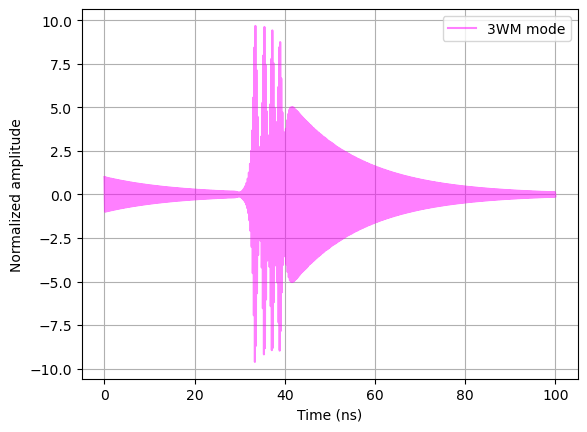

In [3]:
sim.param_dict_nosweep['logchi'] = 6
sim.param_dict_nosweep['logkb'] = 6
sim.param_dict_nosweep['amplG'] = 3

x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
# plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='3WM drive')
# plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='resonator drive')
# plt.plot(t*1e9, x[4,:]/np.max(x[4,:])+4,color=(0.3,0.3,0.3,0.5),label='gain drive')
# plt.plot(t*1e9, x[6,:]/np.max(x[6,:])+6,color=(0,0,1,0.5),label='resonator mode')
plt.plot(t*1e9, x[8,:],color=(1,0,1,0.5),label='3WM mode')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [7]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|██████████████████████████████████████████████████████████████████████████| 12000/12000 [00:08<00:00, 1360.41it/s]

 
...finished GPU solve!


This step below is kind of hacky - I need to better implement different decimation frequencies (although the demodulation will always be one frequency - you can just rerun sim if you need more)

In [230]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

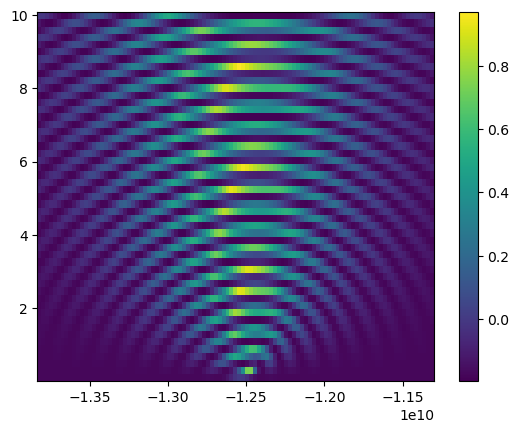

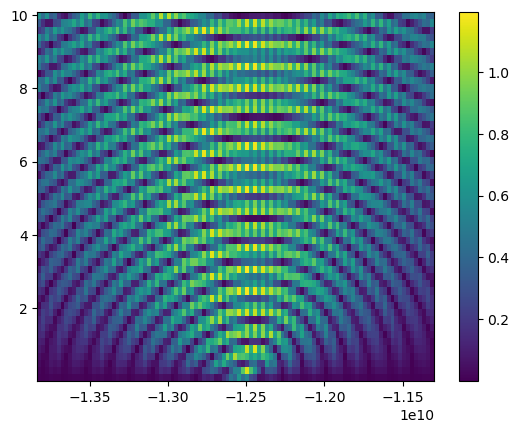

In [231]:
a_nbar = np.sqrt(Id[6,:]**2+Qd[6,:]**2)
b_nbar = np.sqrt(Id[8,:]**2+Qd[8,:]**2)

a_separation = np.sqrt((Id[6,1,:,:,:]-Id[6,0,:,:,:])**2 + (Qd[6,1,:,:,:]-Qd[6,0,:,:,:])**2)
b_separation = np.sqrt((Id[8,1,:,:,:]-Id[8,0,:,:,:])**2 + (Qd[8,1,:,:,:]-Qd[8,0,:,:,:])**2)

wC1 = sim.paramsweep_dict['wC1']
amplC1 = sim.paramsweep_dict['amplC1']

wC1_i = 28
amplC1_i = 10
qb_state = 0

plt.figure(4)
plt.pcolor(wC1, amplC1, 1-a_nbar[qb_state,:, :,-1])
plt.colorbar()

plt.figure(5)
plt.pcolor(wC1, amplC1, b_nbar[qb_state,:, :,-1])
plt.colorbar()

